In [ ]:
# SKCT 727823TUAM035 PRABHAKAR A

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# SKCT 727823TUAM035 PRABHAKAR A
sns.set(style="whitegrid")

In [9]:
df = pd.read_csv("../data/PJME_hourly.csv")



df.head()

,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


In [10]:
print(df.shape)
print(df.columns)
print(df.info())

(145366, 2)
Index(['Datetime', 'PJME_MW'], dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 145366 entries, 0 to 145365
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Datetime  145366 non-null  str    
 1   PJME_MW   145366 non-null  float64
dtypes: float64(1), str(1)
memory usage: 2.2 MB
None


In [12]:
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.sort_values('Datetime')
df = df.set_index('Datetime')

In [13]:
df.isnull().sum()

PJME_MW    0
dtype: int64

In [14]:
df = df.dropna()

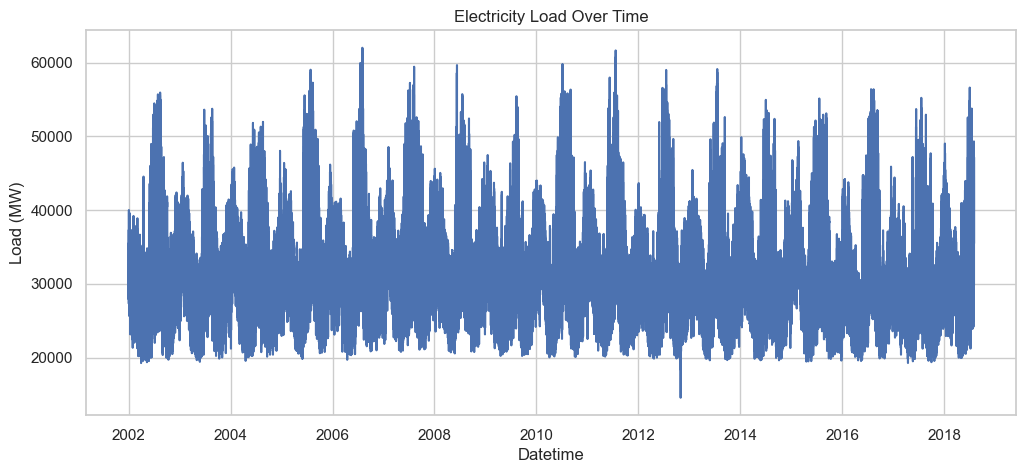

In [16]:
plt.figure(figsize=(12,5))
plt.plot(df.index, df['PJME_MW'])
plt.title("Electricity Load Over Time")
plt.xlabel("Datetime")
plt.ylabel("Load (MW)")
plt.show()

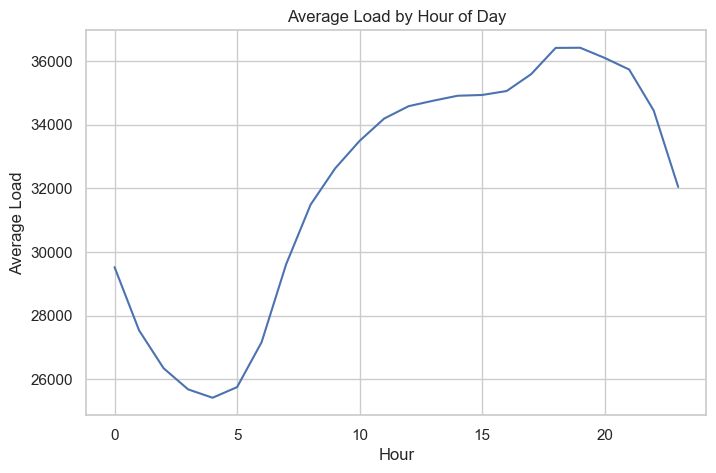

In [17]:
df['hour'] = df.index.hour

hourly_avg = df.groupby('hour')['PJME_MW'].mean()

plt.figure(figsize=(8,5))
sns.lineplot(x=hourly_avg.index, y=hourly_avg.values)
plt.title("Average Load by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Average Load")
plt.show()

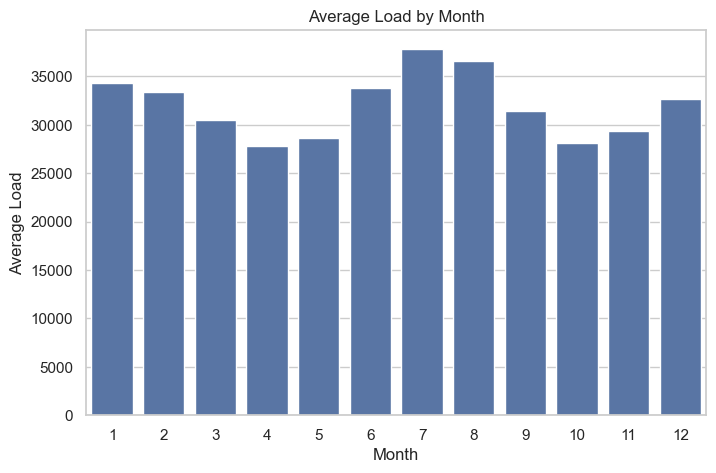

In [18]:
df['month'] = df.index.month

monthly_avg = df.groupby('month')['PJME_MW'].mean()

plt.figure(figsize=(8,5))
sns.barplot(x=monthly_avg.index, y=monthly_avg.values)
plt.title("Average Load by Month")
plt.xlabel("Month")
plt.ylabel("Average Load")
plt.show()

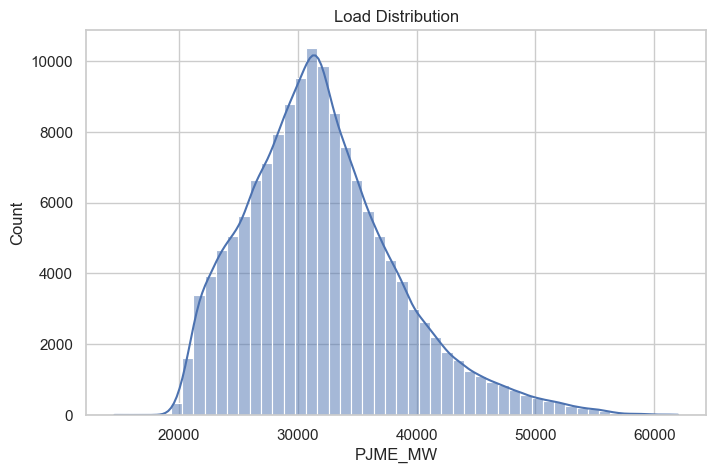

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(df['PJME_MW'], bins=50, kde=True)
plt.title("Load Distribution")
plt.show()

In [20]:
df['dayofweek'] = df.index.dayofweek

In [21]:
df.to_csv("../data/pjm_load_clean.csv")